<a href="https://colab.research.google.com/github/saniananda02/Iris-Flower-Classification/blob/main/unemployment_in_india.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/Unemployment in India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
print(df.shape)
print(df.columns)
df.info()

(768, 7)
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [5]:
# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Rename columns (optional but clean)
df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation'
}, inplace=True)

In [6]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Unemployment_Rate,28
Employed,28
Labour_Participation,28
Area,28


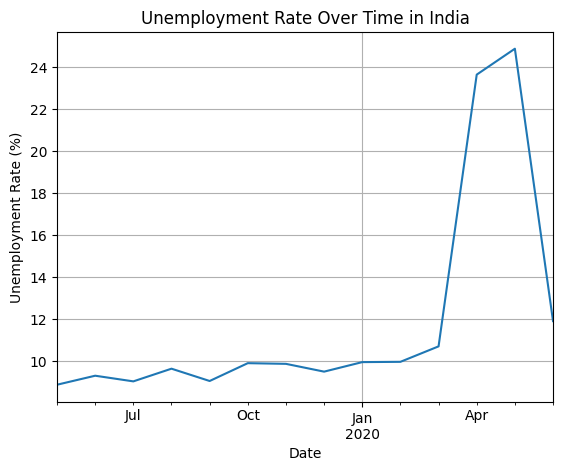

In [7]:
plt.figure()
df.groupby('Date')['Unemployment_Rate'].mean().plot()
plt.title('Unemployment Rate Over Time in India')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid()
plt.show()

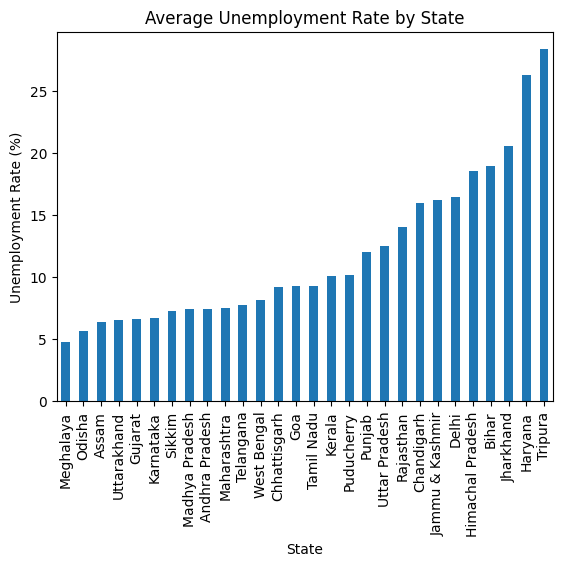

In [8]:
state_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values()

plt.figure()
state_avg.plot(kind='bar')
plt.title('Average Unemployment Rate by State')
plt.xlabel('State')
plt.ylabel('Unemployment Rate (%)')
plt.show()

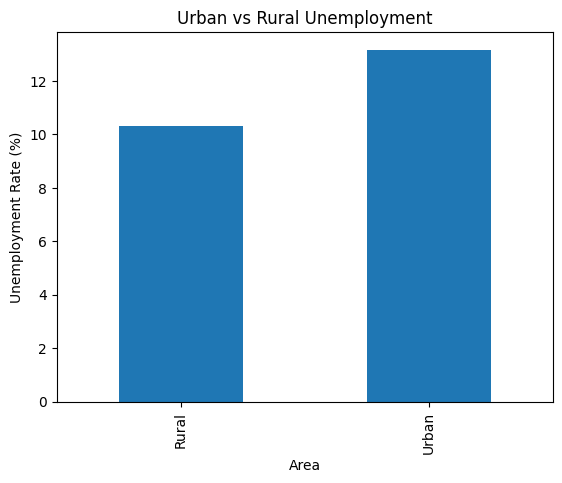

In [9]:
area_avg = df.groupby('Area')['Unemployment_Rate'].mean()

plt.figure()
area_avg.plot(kind='bar')
plt.title('Urban vs Rural Unemployment')
plt.ylabel('Unemployment Rate (%)')
plt.show()

In [10]:
print("Highest unemployment state:", state_avg.idxmax())
print("Lowest unemployment state:", state_avg.idxmin())
print("\nUrban vs Rural:\n", area_avg)

Highest unemployment state: Tripura
Lowest unemployment state: Meghalaya

Urban vs Rural:
 Area
Rural    10.324791
Urban    13.166614
Name: Unemployment_Rate, dtype: float64
